In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#input data

import pandas as pd

data_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_train.csv')
data_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_test.csv')

In [13]:
#ekstrak file

x_train = data_train['clean_tweet']
y_train = data_train['sentimen']
x_test = data_test['clean_tweet']
y_test = data_test['sentimen']

In [8]:
# = * 50
# Percobaan ke 4: GRID SEARCH
# = * 50

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


In [9]:
#Buat Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

In [16]:
# Parameter Grid

param_grid = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'tfidf__min_df':[2, 3],
    'tfidf__sublinear_tf': [True, False],
    'lr__C': [0.1, 1, 10],
    'lr__class_weight': [None, 'balanced']
}

In [17]:
# Grid Search

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [18]:
print("🔍 Mencari parameter terbaik...")
grid.fit(x_train, y_train)  # Gunakan teks asli, bukan TF-IDF
print(f"\n✅ Parameter terbaik: {grid.best_params_}")
print(f"✅ Akurasi CV terbaik: {grid.best_score_:.4f}")

🔍 Mencari parameter terbaik...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

✅ Parameter terbaik: {'lr__C': 0.1, 'lr__class_weight': 'balanced', 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}
✅ Akurasi CV terbaik: 0.6061


In [20]:
# Evaluasi
from sklearn.metrics import accuracy_score

y_pred_grid = grid.predict(x_test)
acc_grid = accuracy_score(y_test, y_pred_grid)
print(f"✅ Akurasi Test: {acc_grid:.4f}")

✅ Akurasi Test: 0.6226



 📊 HASIL EVALUASI

🎯 Akurasi: 0.6226 (62.26%)

📋 Classification Report:
              precision    recall  f1-score   support

     negatif       0.59      0.70      0.64       115
      netral       0.67      0.62      0.64       118
     positif       0.62      0.56      0.59       130

    accuracy                           0.62       363
   macro avg       0.63      0.63      0.62       363
weighted avg       0.63      0.62      0.62       363


🔢 Confusion Matrix:
[[80 12 23]
 [23 73 22]
 [33 24 73]]


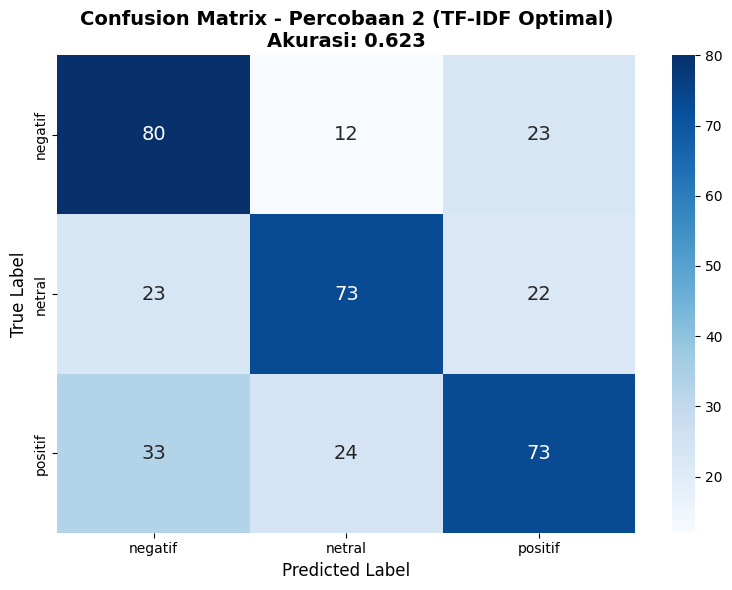

In [23]:
# ============================================
# Visualisasi
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for unique if needed, though sorted(y_train.unique()) is fine

print("\n" + "="*60)
print(" 📊 HASIL EVALUASI")
print("="*60)

# Get class names from y_train for consistent ordering
class_names = sorted(y_train.unique())

# Accuracy
accuracy = accuracy_score(y_test, y_pred_grid)
print(f"\n🎯 Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_grid, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_grid)
print(f"\n🔢 Confusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 14})
plt.title(f'Confusion Matrix - Percobaan 2 (TF-IDF Optimal)\nAkurasi: {accuracy:.3f}',
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('percobaan1_confusion_matrix.png', dpi=150)
plt.show()